In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("dim_locations_cleaned.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10, 8)


,Location_ID,Location_Name,Water_Body_Type,Latitude,Longitude,City,State,Nearby_Industry_Type
0,Loc-101,Hudson River North,River,40.7128,-74.0060,New York,Ny,Textile & Apparel
1,Loc-102,Lake Michigan Central,Lake,41.8781,-87.6298,Chicago,Il,Manufacturing
2,Loc-103,Bay Area Estuary,Estuary,37.7749,-122.4194,San Francisco,Ca,Tech & Commercial
3,Loc-104,City Wwtp Outlet,Wwtp Effluent,40.7306,-73.9352,New York,Ny,Municipal Sewage
4,Loc-105,Puget Sound Coastal,Coastal,47.6062,-122.3321,Seattle,Wa,Maritime & Shipping


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Location_ID           10 non-null     object 
 1   Location_Name         10 non-null     object 
 2   Water_Body_Type       10 non-null     object 
 3   Latitude              10 non-null     float64
 4   Longitude             10 non-null     float64
 5   City                  10 non-null     object 
 6   State                 10 non-null     object 
 7   Nearby_Industry_Type  10 non-null     object 
dtypes: float64(2), object(6)
memory usage: 772.0+ bytes


In [5]:
df.isnull().sum()

Location_ID             0
Location_Name           0
Water_Body_Type         0
Latitude                0
Longitude               0
City                    0
State                   0
Nearby_Industry_Type    0
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
df["Water_Body_Type"].value_counts()

Water_Body_Type
River            3
Lake             2
Estuary          2
Wwtp Effluent    1
Coastal          1
Wetland          1
Name: count, dtype: int64

In [8]:
features = [
    "Latitude",
    "Longitude",
    "City",
    "State",
    "Nearby_Industry_Type"
]
X = df[features]

In [9]:
y = df["Water_Body_Type"]

In [10]:
categorical_features = [
    "City",
    "State",
    "Nearby_Industry_Type"
]

In [11]:
numerical_features = [
    "Latitude",
    "Longitude"
]

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [24]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [25]:
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 8
Testing records: 2


In [26]:
#Random forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [27]:
model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("random_forest", rf_model)
    ]
)

In [28]:
#model training
model.fit(X_train, y_train)
print("Model training completed successfully!")

Model training completed successfully!


In [29]:
#model prediction
y_pred = model.predict(X_test)
print("Prediction completed!")

Prediction completed!


In [30]:
prediction_results = pd.DataFrame({
    "Actual_Water_Body_Type": y_test.values,
    "Predicted_Water_Body_Type": y_pred
})
prediction_results

,Actual_Water_Body_Type,Predicted_Water_Body_Type
0,Lake,River
1,Lake,River


In [31]:
prediction_results = df.loc[
    X_test.index,
    [
        "Location_ID",
        "Location_Name",
        "City",
        "State",
        "Water_Body_Type"
    ]
].copy()

In [32]:
prediction_results.rename(
    columns={
        "Water_Body_Type": "Actual_Water_Body_Type"
    },
    inplace=True
)

In [33]:
prediction_results["Predicted_Water_Body_Type"] = y_pred

In [34]:
prediction_results

,Location_ID,Location_Name,City,State,Actual_Water_Body_Type,Predicted_Water_Body_Type
8,Loc-109,Lake Erie West,Cleveland,Oh,Lake,River
1,Loc-102,Lake Michigan Central,Chicago,Il,Lake,River


In [36]:
prediction_results.to_csv(
    "location_predictions.csv",
    index=False
)
print("location_predictions.csv created successfully!")

location_predictions.csv created successfully!


In [41]:
#Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [42]:
accuracy = accuracy_score(
    y_test,
    y_pred
)
print("Accuracy:", accuracy)

Accuracy: 0.0


In [43]:
print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 0.00%


In [44]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)
print(
    f"Precision: {precision:.3f}"
)

Precision: 0.000


In [45]:
recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(
    f"Recall: {recall:.3f}"
)

Recall: 0.000


In [46]:
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(
    f"F1 Score: {f1:.3f}"
)

F1 Score: 0.000


In [47]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Lake       0.00      0.00      0.00       2.0
       River       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



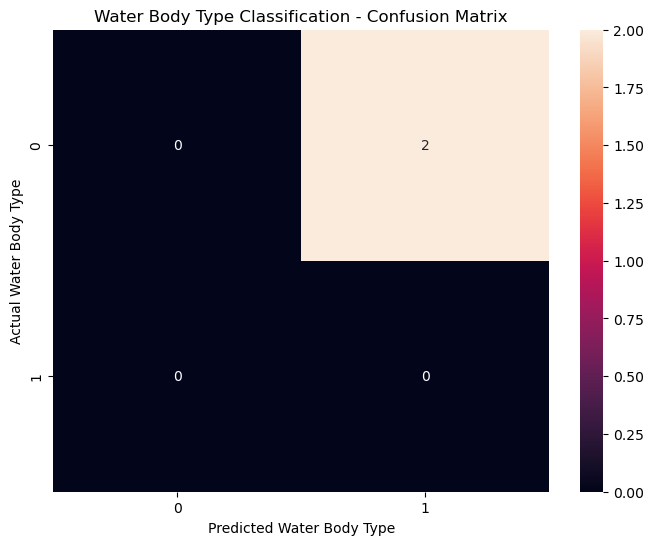

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)
plt.xlabel("Predicted Water Body Type")
plt.ylabel("Actual Water Body Type")
plt.title("Water Body Type Classification - Confusion Matrix")
plt.show()

In [55]:
#Final evaluation
evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})
evaluation_results

,Metric,Score
0,Accuracy,0.0
1,Precision,0.0
2,Recall,0.0
3,F1 Score,0.0
